# Simple model, based on lookup table
- The goal of this is to generate a simple lookup table, based only on player name and shot type
- I want to show that our current models do not much more than looking at the player name and the shot type

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from app.data_providers import test_train_dataset
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import FunctionTransformer

from sklearn.calibration import CalibrationDisplay

from sklearn.pipeline import FeatureUnion
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer

from sklearn.metrics import roc_auc_score, f1_score
from sklearn.metrics import classification_report

from imblearn.over_sampling import RandomOverSampler

from xgboost import XGBClassifier

import joblib

from copy import deepcopy

pd.set_option('display.max_columns', None)

In [2]:
data = test_train_dataset()

X_train = data['train'].drop('SHOT_MADE_FLAG', axis=1)
y_train = data['train']['SHOT_MADE_FLAG']

X_test = data['test'].drop('SHOT_MADE_FLAG', axis=1)
y_test = data['test']['SHOT_MADE_FLAG']

Repo card metadata block was not found. Setting CardData to empty.


In [7]:
train_lookup = X_train.copy()

train_lookup["y"] = y_train.values

lookup_table = (
    train_lookup
    .groupby(
        ["MAIN_ACTION_TYPE", "PLAYER_NAME"]
    )["y"]
    .mean()
    .reset_index()
    .rename(columns={"y": "p_make"})
)

lookup_table.head()

,MAIN_ACTION_TYPE,PLAYER_NAME,p_make
0,Dunk,Anthony Davis,0.914733
1,Dunk,Chris Paul,0.950000
2,Dunk,Dirk Nowitzki,0.963731
3,Dunk,Draymond Green,0.920110
4,Dunk,Dwyane Wade,0.931655


In [8]:
lookup_dict = {
    (
        row["MAIN_ACTION_TYPE"],
        row["PLAYER_NAME"]
    ): row["p_make"]
    
    for _, row in lookup_table.iterrows()
}

In [9]:
global_mean = y_train.mean()

def lookup_predict(X):

    probs = []

    for _, row in X.iterrows():

        key = (
            row["MAIN_ACTION_TYPE"],
            row["PLAYER_NAME"]
        )

        # fallback to global mean if unseen
        p = lookup_dict.get(key, global_mean)

        probs.append(p)

    probs = np.array(probs)

    preds = (probs >= 0.5).astype(int)

    return preds, probs

In [10]:
y_pred_lookup, y_proba_lookup = lookup_predict(X_test)

from sklearn.metrics import (
    roc_auc_score,
    classification_report
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_proba_lookup)
)

print(
    classification_report(
        y_test,
        y_pred_lookup
    )
)

ROC-AUC: 0.7085715226832207
              precision    recall  f1-score   support

         0.0       0.60      0.67      0.63     46437
         1.0       0.72      0.66      0.69     61245

    accuracy                           0.66    107682
   macro avg       0.66      0.66      0.66    107682
weighted avg       0.67      0.66      0.66    107682



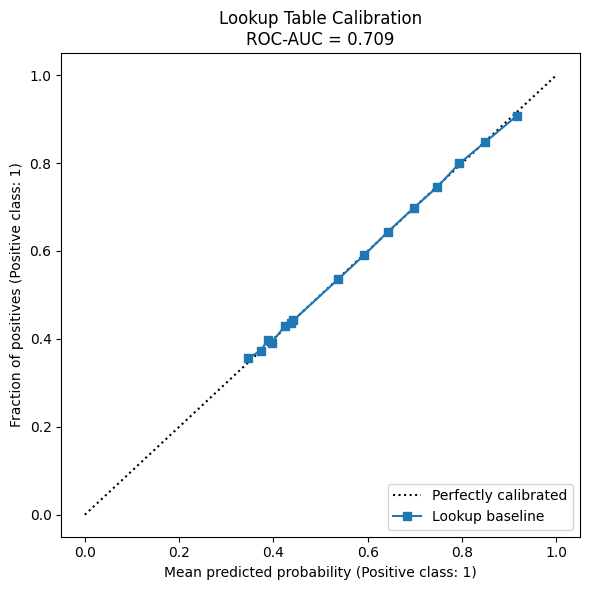

In [11]:
auc = roc_auc_score(y_test, y_proba_lookup)

fig, ax = plt.subplots(figsize=(6, 6))

CalibrationDisplay.from_predictions(
    y_test,
    y_proba_lookup,
    n_bins=15,
    strategy="quantile",
    name="Lookup baseline",
    ax=ax
)

ax.set_title(
    f"Lookup Table Calibration\n"
    f"ROC-AUC = {auc:.3f}"
)

plt.tight_layout()
plt.show()